# Objetivo
Implementar su propia hibridización entre dos metaheurísticas, y evalúen su desempeño frente a una función particularmente desafiante: **la función de Michalewicz**.

\begin{equation}
f(\vec(x)) = -\sum^{d}_{i = 1} sin(x_i)[sin(\frac{ix_i^2}{\pi})]^{2m}
\end{equation}

La función es usualmente evaluada en el hipercubo x! ∈ [0, 𝜋] ∀ 𝑖 = 1,2, … , 𝑑.
Utilice 𝒅 = 𝟓.

Equipo:
Fernando Leon Franco  
Rodrigo Mendoza Rodriguez

In [ ]:
import numpy as np
import plotly.graph_objects as go

def michalewicz(X, Y, m=10):
    term1 = -np.sin(X) * (np.sin((1 * X**2)/np.pi))**(2*m)
    term2 = -np.sin(Y) * (np.sin((2 * Y**2)/np.pi))**(2*m)
    return term1 + term2

x = np.linspace(0, np.pi, 400)
y = np.linspace(0, np.pi, 400)
X, Y = np.meshgrid(x, y)
Z = michalewicz(X, Y)

surface = go.Surface(
    x = X,
    y = Y,
    z = Z,
    colorscale='Viridis',
    showscale=True
)

fig = go.Figure(data=[surface])

fig.update_layout(
    title="Función de Michalewicz",
    scene=dict(
        xaxis_title="x",
        yaxis_title="y",
        zaxis_title="f(x, y)"
    ),
    width=900,
    height=700
)

fig.show()

x: [2.32272507 1.59792983 1.2794236  1.09297712 1.70322963]
f(x): -4.287523289197823
Minimo -4.287523289197823
Maximo -1.899815603550536
Tiempo: 0.9162230491638184
Media: -3.4717212726578146
Desviacion estandar: 0.6438870134374995


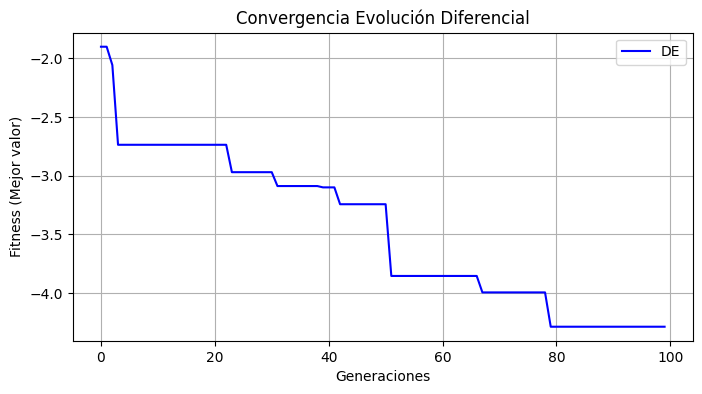

In [ ]:
import random
import math
import time
import pandas as pd
import matplotlib.pyplot as plt

def michalewicz(x, m=10):
    x = np.array(x)
    d = len(x)
    i = np.arange(1, d+1)
    return -np.sum(np.sin(x) * (np.sin((i * x**2)/np.pi))**(2*m))

def ini_pob(tam, d, xmin, xmax):
    return [np.random.uniform(xmin, xmax, d) for i in range(tam)]

def mutacion(poblacion, F, i):
    idxs = [idx for idx in range(len(poblacion)) if idx != i]
    r1, r2, r3 = random.sample(idxs, 3)
    return poblacion[r1] + F * (poblacion[r2] - poblacion[r3])

def cruza(ind, mut, CR):
    d = len(ind)
    j_rand = random.randint(0, d - 1)
    return np.array([mut[j] if (random.random() < CR or j == j_rand) else ind[j] for j in range(d)])

def seleccion(ind, trial):
    return trial if michalewicz(trial) < michalewicz(ind) else ind

def ejecutar_DE(d=5, tam_pob=50, generaciones=100, F=0.8, CR=0.9, xmin=0, xmax=np.pi):
    poblacion = ini_pob(tam_pob, d, xmin, xmax)
    history = []

    start = time.time()
    for g in range(generaciones):
        nueva_pob = []
        best_gen_fitness = float('inf')

        for i in range(tam_pob):
            mut = np.clip(mutacion(poblacion, F, i), xmin, xmax)
            trial = np.clip(cruza(poblacion[i], mut, CR), xmin, xmax)
            nuevo = seleccion(poblacion[i], trial)
            nueva_pob.append(nuevo)

            fit = michalewicz(nuevo)
            if fit < best_gen_fitness: best_gen_fitness = fit

        poblacion = nueva_pob
        history.append(best_gen_fitness)

    fitness_final = [michalewicz(p) for p in poblacion]
    best_idx = np.argmin(fitness_final)

    return poblacion[best_idx], fitness_final[best_idx], history, (time.time() - start), np.mean(history), np.std(history)

diferencial = ejecutar_DE()

print('x:', diferencial[0])
print("f(x):", diferencial[1])
print('Minimo', np.array(min(diferencial[2])))
print('Maximo', np.array(max(diferencial[2])))
print("Tiempo:", diferencial[3])
print("Media:", diferencial[4])
print("Desviacion estandar:", diferencial[5])

plt.figure(figsize=(8, 4))
plt.plot(diferencial[2], color='blue', label='DE')
plt.title('Convergencia Evolución Diferencial')
plt.xlabel('Generaciones')
plt.ylabel('Fitness (Mejor valor)')
plt.legend()
plt.grid(True)
plt.show()

x: [2.2212782  1.56382579 2.22464682 1.91488152 1.72433023]
f(x): -4.494050683862023
Minimo -4.494050683862023
Maximo -0.9876578254521069
Tiempo: 0.06213855743408203
Media: -4.1464201427773935
Desviacion estandar: 0.8589173499375343


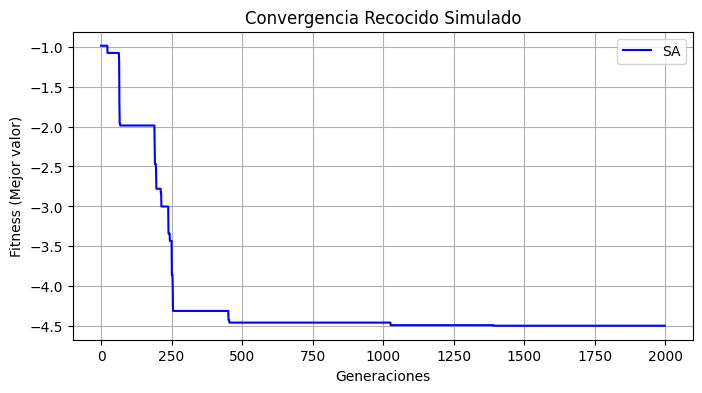

In [ ]:
def solucion_vecina(x, perturbacion, xmin, xmax):
    x_new = x + np.random.uniform(-perturbacion, perturbacion, size=len(x))
    return np.clip(x_new, xmin, xmax)

def ejecutar_SA(x_inicio=None, d=5, iteraciones=2000, T0=6.0, alpha=0.99, perturbacion=0.05, xmin=0, xmax=np.pi):
    if x_inicio is None:
        x_actual = np.random.uniform(xmin, xmax, d)
    else:
        x_actual = np.array(x_inicio)

    f_actual = michalewicz(x_actual)
    mejor_x = x_actual.copy()
    mejor_f = f_actual
    T = T0
    history = []

    start = time.time()
    for i in range(iteraciones):
        x_vecina = solucion_vecina(x_actual, perturbacion, xmin, xmax)
        f_vecina = michalewicz(x_vecina)

        delta = f_vecina - f_actual
        if delta < 0 or random.random() < math.exp(-delta / T):
            x_actual = x_vecina
            f_actual = f_vecina

        if f_actual < mejor_f:
            mejor_x = x_actual.copy()
            mejor_f = f_actual

        T *= alpha
        history.append(mejor_f)

    return mejor_x, mejor_f, history, (time.time() - start), np.mean(history), np.std(history)

sa = ejecutar_SA()

print('x:', sa[0])
print("f(x):", sa[1])
print('Minimo', np.array(min(sa[2])))
print('Maximo', np.array(max(sa[2])))
print("Tiempo:", sa[3])
print("Media:", sa[4])
print("Desviacion estandar:", sa[5])

plt.figure(figsize=(8, 4))
plt.plot(sa[2], color='blue', label='SA')
plt.title('Convergencia Recocido Simulado')
plt.xlabel('Generaciones')
plt.ylabel('Fitness (Mejor valor)')
plt.legend()
plt.grid(True)
plt.show()

Tiempo: 12.202562093734741

Resultados Híbrido:
Mejor: -4.68179
Peor: -3.87935
Media: -4.50431
Std: 0.16688
Salida 1: [2.23061115 1.57032338 1.28113264 1.92190585 1.71434421]
Salida 2: [2.21051784 1.58791604 1.28222639 1.9232173  1.71730678]
Salida 3: [2.19953613 1.57440823 1.28474173 2.48514723 0.99098492]
Salida 4: [2.19856989 1.56888622 1.2775403  1.10939724 1.71518885]
Salida 5: [2.18966946 1.54763906 1.2825679  1.94008756 2.21616768]
Salida 6: [2.19086936 1.58188845 1.28244808 1.11943702 1.71683391]
Salida 7: [2.19498598 1.55982925 1.29269819 1.91814045 2.21665402]
Salida 8: [2.20316979 1.58196262 1.27863188 1.12405651 1.72195058]
Salida 9: [2.22071064 1.57019752 2.22023681 1.92114429 1.71809137]
Salida 10: [2.19647775 1.55290939 1.27637551 1.92166708 1.72153912]
Salida 11: [2.19769796 1.56510214 2.21159639 1.92455066 1.71486349]
Salida 12: [2.16675521 1.53382941 1.28516602 1.12007022 1.72038646]
Salida 13: [2.20010058 1.58664616 1.28261415 1.92621723 1.71956384]
Salida 14: [2.183

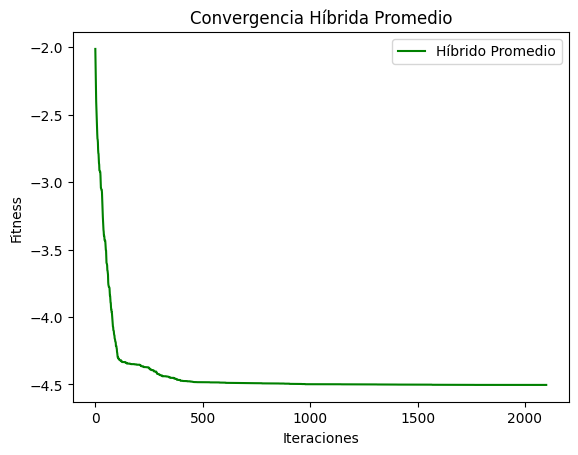

In [ ]:
# --- FUNCIÓN HÍBRIDA---
def ejecutar_hibrido(d, xmin, xmax):
    best_de, fit_de, hist_de, t_de, mean_de, std_de = ejecutar_DE(d=d, generaciones=100, xmin=xmin, xmax=xmax)
    best_hy, fit_hy, hist_sa, t_sa, mean_sa, std_sa = ejecutar_SA(x_inicio=best_de, d=d, iteraciones=2000, perturbacion=0.05, T0=0.5, xmin=xmin, xmax=xmax)

    total_hist = hist_de + hist_sa
    total_time = t_de + t_sa
    return best_hy, fit_hy, total_hist, total_time

start = time.time()
datos_hy = []
curvas_hy = []
tiempos_hy = []


lista_salidas= []
for i in range(30):
    r, fit, hist, t = ejecutar_hibrido(5, 0, np.pi)
    lista_salidas.append(r)
    datos_hy.append(fit)
    curvas_hy.append(hist)
    tiempos_hy.append(t)




# --- RESULTADOS ---
print('Tiempo:', time.time() - start)
print(f"\nResultados Híbrido:")

print(f"Mejor: {np.min(datos_hy):.5f}")
print(f"Peor: {np.max(datos_hy):.5f}")
print(f"Media: {np.mean(datos_hy):.5f}")
print(f"Std: {np.std(datos_hy):.5f}")

for i in range(len(lista_salidas)):
    print(f"Salida {i+1}: {lista_salidas[i]}")
# Gráfica promedio
min_len = min(len(c) for c in curvas_hy)
promedio_curva = np.mean([c[:min_len] for c in curvas_hy], axis=0)

plt.plot(promedio_curva, color='green', label='Híbrido Promedio')
plt.title('Convergencia Híbrida Promedio')
plt.xlabel('Iteraciones')
plt.ylabel('Fitness')
plt.legend()
plt.show()

In [ ]:
# --- FUNCIÓN HÍBRIDA---
def ejecutar_hibrido(d, xmin, xmax):
    best_hy, fit_hy, hist_sa, t_sa, mean_sa, std_sa = ejecutar_SA(x_inicio=best_de, d=d, iteraciones=2000, perturbacion=0.05, T0=0.5, xmin=xmin, xmax=xmax)
    best_de, fit_de, hist_de, t_de, mean_de, std_de = ejecutar_DE(d=d, generaciones=100, xmin=xmin, xmax=xmax)

    total_hist = hist_de + hist_sa
    total_time = t_de + t_sa
    return best_hy, fit_hy, total_hist, total_time

start = time.time()
datos_hy = []
curvas_hy = []
tiempos_hy = []

for i in range(30):
    _, fit, hist, t = ejecutar_hibrido(5, 0, np.pi)
    datos_hy.append(fit)
    curvas_hy.append(hist)
    tiempos_hy.append(t)

# --- RESULTADOS ---
print('Tiempo:', time.time() - start)
print(f"\nResultados Híbrido:")
print(f"Mejor: {np.min(datos_hy):.5f}")
print(f"Peor: {np.max(datos_hy):.5f}")
print(f"Media: {np.mean(datos_hy):.5f}")
print(f"Std: {np.std(datos_hy):.5f}")

# Gráfica promedio
min_len = min(len(c) for c in curvas_hy)
promedio_curva = np.mean([c[:min_len] for c in curvas_hy], axis=0)

plt.plot(promedio_curva, color='green', label='Híbrido Promedio')
plt.title('Convergencia Híbrida Promedio')
plt.xlabel('Iteraciones')
plt.ylabel('Fitness')
plt.legend()
plt.show()